# European Day-Ahead Electricity Price Forecasting (2022)

**Author:** Uthman (Usman Kabir Turajo)

This notebook is the end-to-end walkthrough for the project: exploratory analysis of hourly day-ahead
electricity prices across six European markets during the 2022 energy crisis, followed by a machine-learning
model that forecasts **Germany's day-ahead price 24 hours in advance**.

**Contents**
1. Data loading & cleaning
2. Exploratory data analysis (trends, seasonality, volatility, negative prices, cross-market correlation)
3. Feature engineering
4. Forecasting models (naive baseline → linear → random forest → XGBoost)
5. Evaluation & feature importance
6. Takeaways


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 10)
%matplotlib inline


## 1. Data loading & cleaning

The raw dataset has one row per hour for 2022, with a `date` and `hour` ("HH:00 - HH:00") column, and a
day-ahead price (EUR/MWh) for France, Italy, Belgium, Spain, the UK, and Germany.

`data_loader.py` parses these into a proper hourly `DatetimeIndex`, reindexes to a complete hourly grid
for the year (so any missing hours become explicit `NaN`s rather than silent gaps), and forward-fills
short gaps (≤3 hours).

In [2]:
from data_loader import load_raw, load_clean, COUNTRIES

raw = load_raw()
df = load_clean()

print("Raw shape:", raw.shape)
print("Clean shape:", df.shape, "| date range:", df.index.min(), "to", df.index.max())
df.head()


Raw shape: (8761, 8)
Clean shape: (8760, 6) | date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00


,france,italy,belgium,spain,uk,germany
timestamp,,,,,,
2022-01-01 00:00:00,89.06,170.28,82.02,145.86,0.27,50.05
2022-01-01 01:00:00,78.48,155.72,67.07,114.90,-0.01,41.33
2022-01-01 02:00:00,85.16,147.09,75.11,113.87,0.27,43.22
2022-01-01 03:00:00,50.00,91.00,50.91,97.80,-0.01,45.46
2022-01-01 04:00:00,37.67,104.00,37.67,97.80,-0.01,37.67


In [3]:
missing = df.isna().sum()
print("Missing hourly values per country after cleaning:")
missing


Missing hourly values per country after cleaning:


france        0
italy         0
belgium       0
spain         0
uk         1416
germany       0
dtype: int64

**Data quality note:** the UK series has ~1,400 missing hours (~16%) even after cleaning — these are
genuine gaps in the source data (e.g. all of 22 April 2022 is missing), not artifacts of our processing.
We leave these as `NaN` rather than fabricate values, and exclude the UK from the forecasting target for
this reason (it's used only as a descriptive comparison in the EDA).

## 2. Exploratory Data Analysis

Full EDA figure generation lives in `src/eda.py` — we re-display the saved figures here (and could
re-run `eda.run_all()` directly, which recomputes everything from `df`).

In [4]:
from eda import run_all
df, stats, neg_counts = run_all()
stats.round(1)


Summary stats:
           count        mean         std     min       25%      50%      75%  \
france   8760.0  275.892326  145.814772   -1.44  183.0625  239.335  350.000   
italy    8760.0  307.595284  136.944979    1.00  211.8950  266.645  385.000   
belgium  8760.0  244.545660  134.648658 -100.00  157.7275  219.865  315.085   
spain    8760.0  167.538025   69.442260    0.00  125.0000  163.565  206.410   
uk       7344.0  222.971153  112.847600  -30.00  146.0000  207.460  285.070   
germany  8760.0  235.460071  142.802139  -19.04  134.2775  208.375  310.080   

             max  
france   2987.78  
italy     871.00  
belgium   871.00  
spain     700.00  
uk        705.47  
germany   871.00  

Negative price hour counts:
 belgium    112
germany     69
uk          51
france       4
italy        0
spain        0
dtype: int64

Figures written to /home/claude/repo/outputs/figures


,count,mean,std,min,25%,50%,75%,max
france,8760.0,275.9,145.8,-1.4,183.1,239.3,350.0,2987.8
italy,8760.0,307.6,136.9,1.0,211.9,266.6,385.0,871.0
belgium,8760.0,244.5,134.6,-100.0,157.7,219.9,315.1,871.0
spain,8760.0,167.5,69.4,0.0,125.0,163.6,206.4,700.0
uk,7344.0,223.0,112.8,-30.0,146.0,207.5,285.1,705.5
germany,8760.0,235.5,142.8,-19.0,134.3,208.4,310.1,871.0


### 2.1 The 2022 energy crisis, in one chart

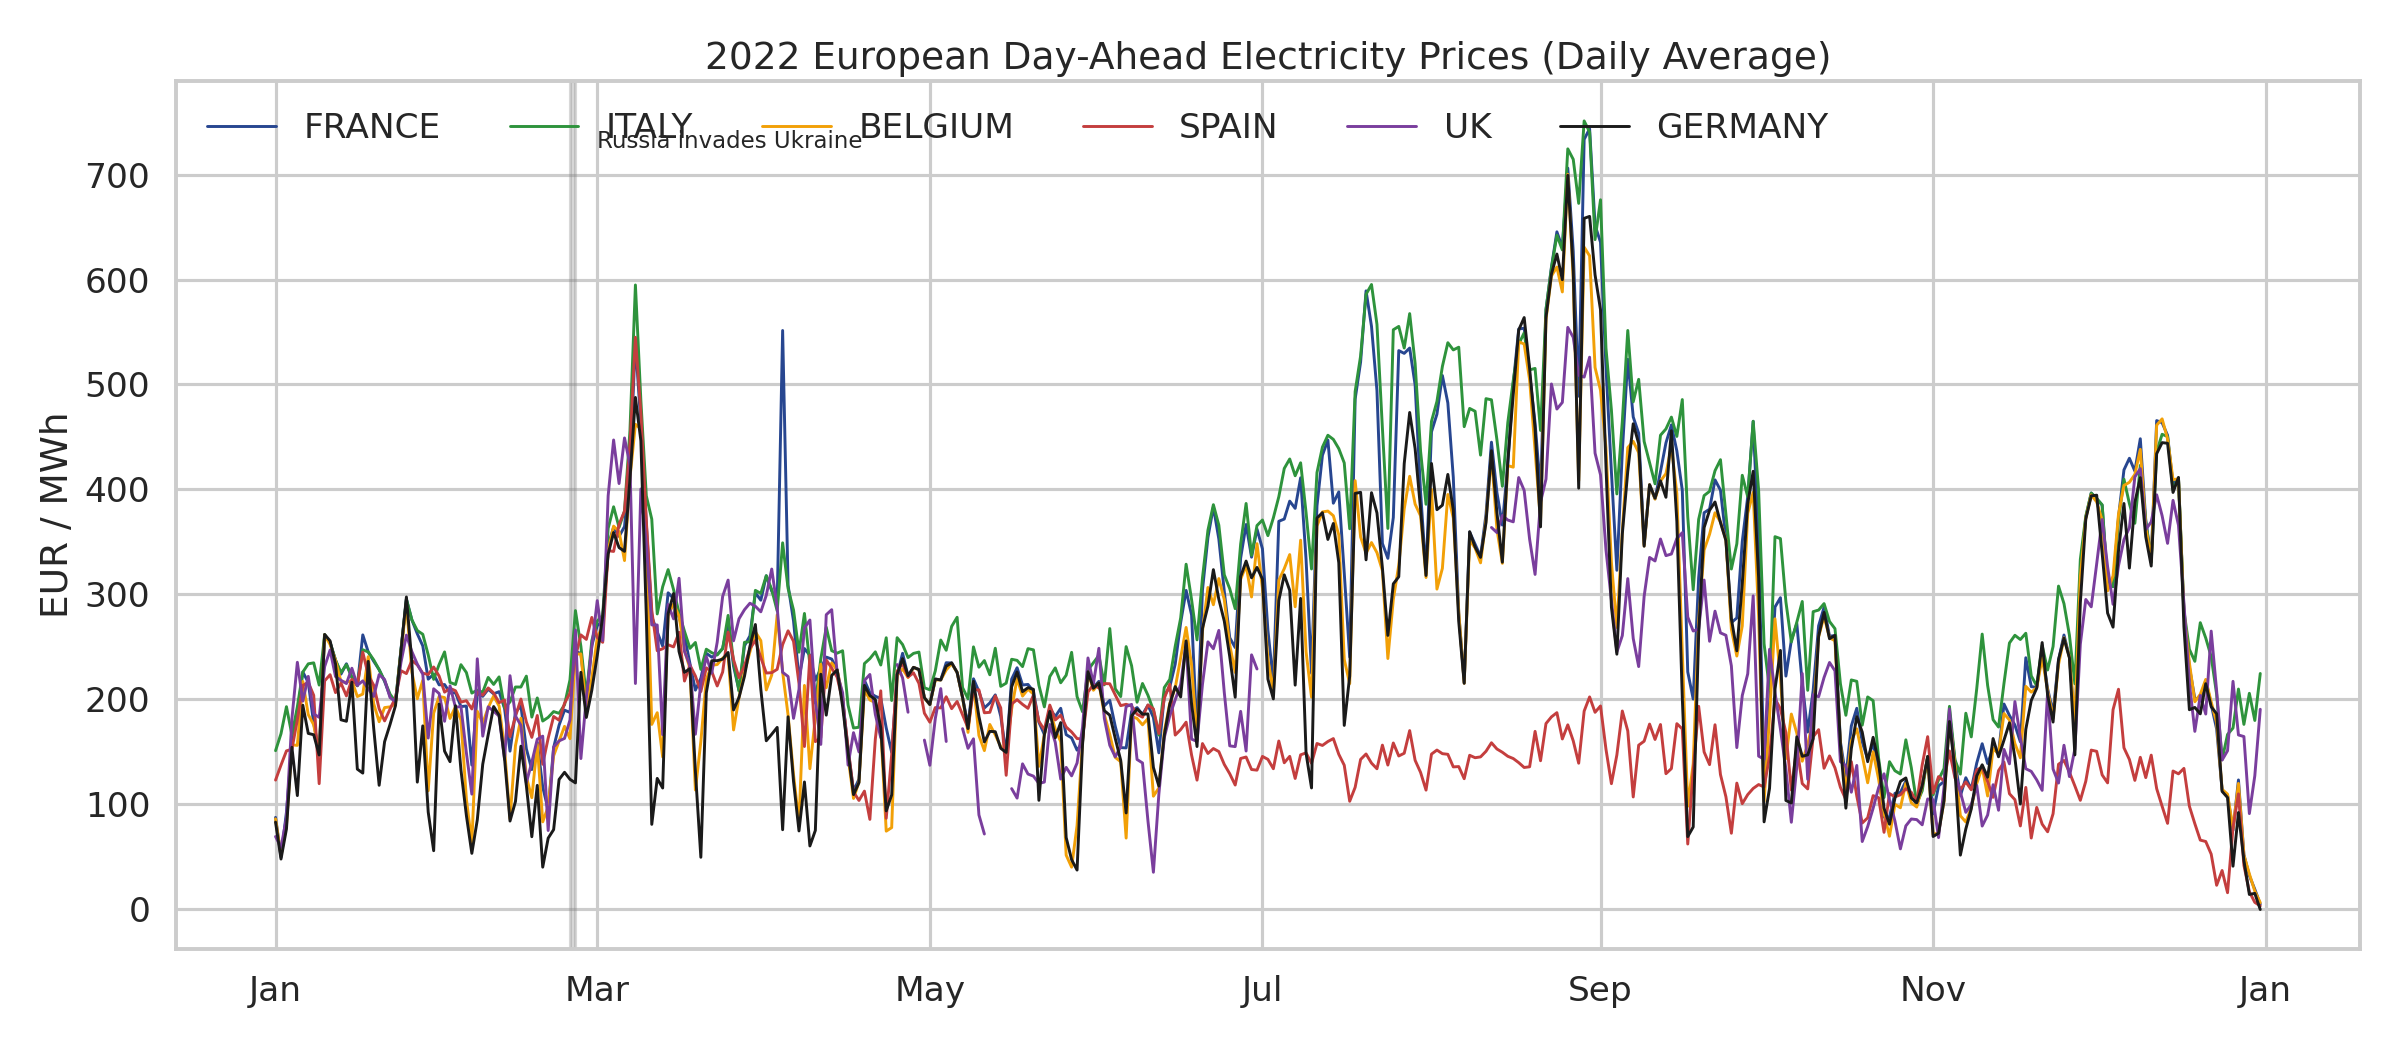

In [5]:
display(Image(filename="../outputs/figures/01_full_year_trend.png"))

Prices across all six markets climb through the year and peak in **late August 2022**, driven by
the cutoff of Russian pipeline gas to Europe (gas sets the marginal price in most of these markets) —
before easing off as European storage filled and a mild autumn reduced demand.

### 2.2 Monthly price distributions

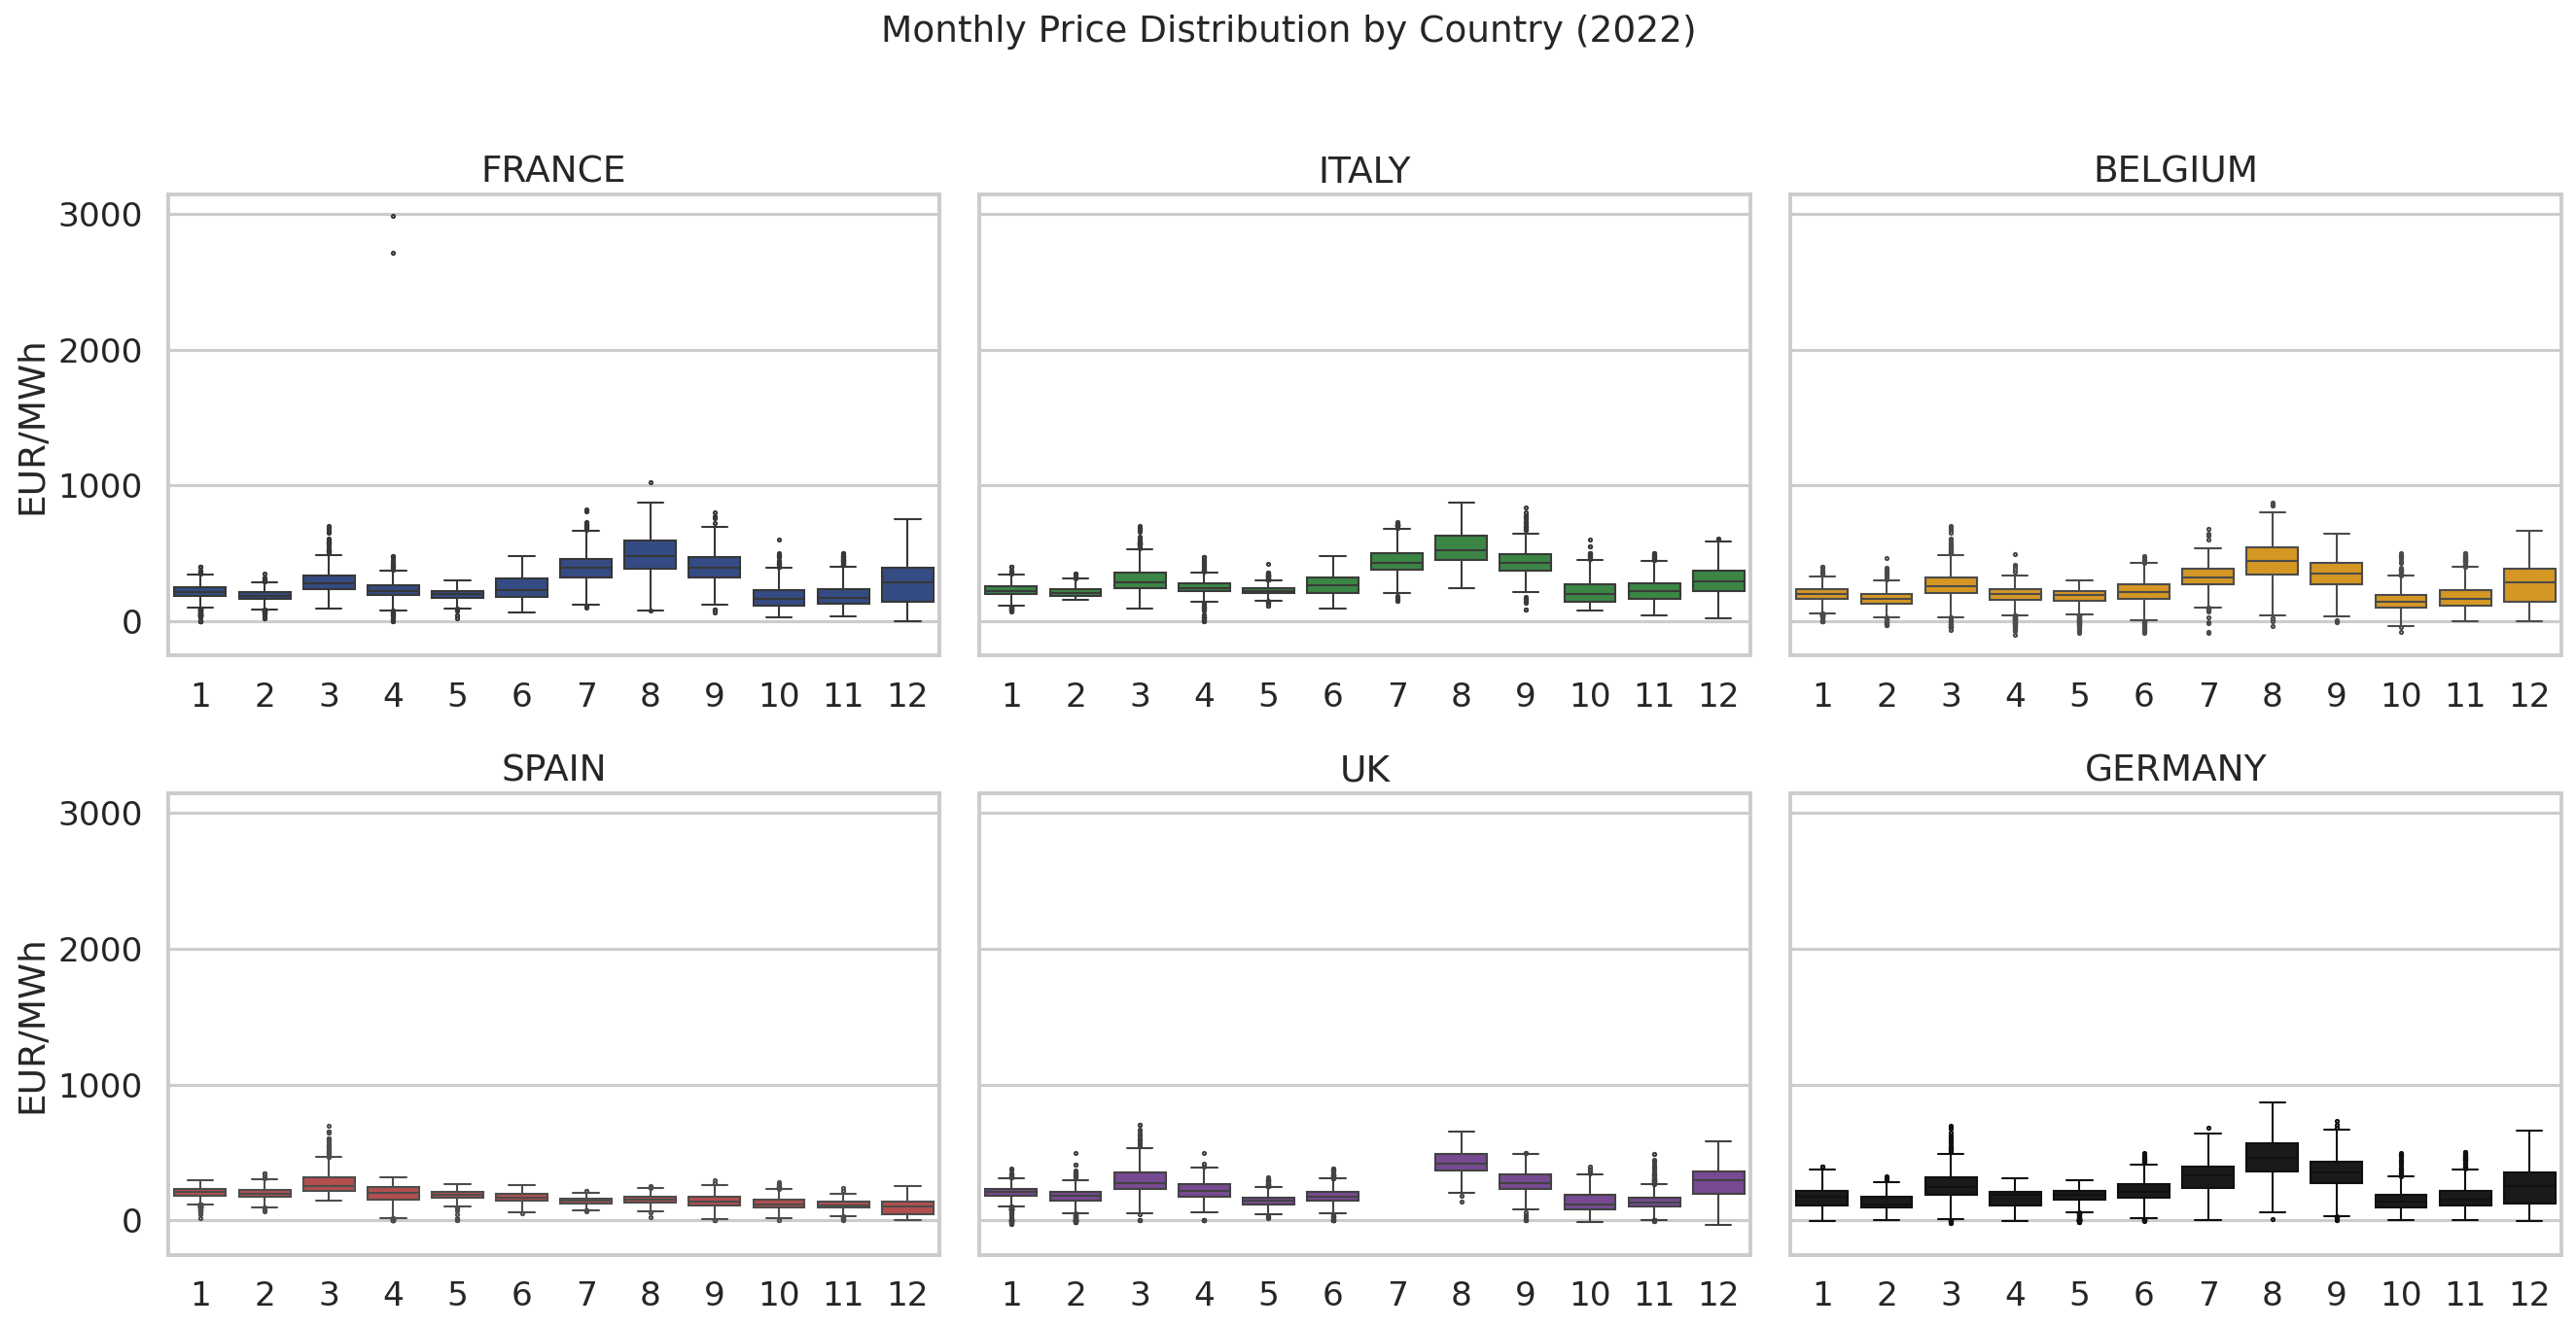

In [6]:
display(Image(filename="../outputs/figures/02_monthly_boxplots.png"))

### 2.3 Intraday shape: when is power expensive?

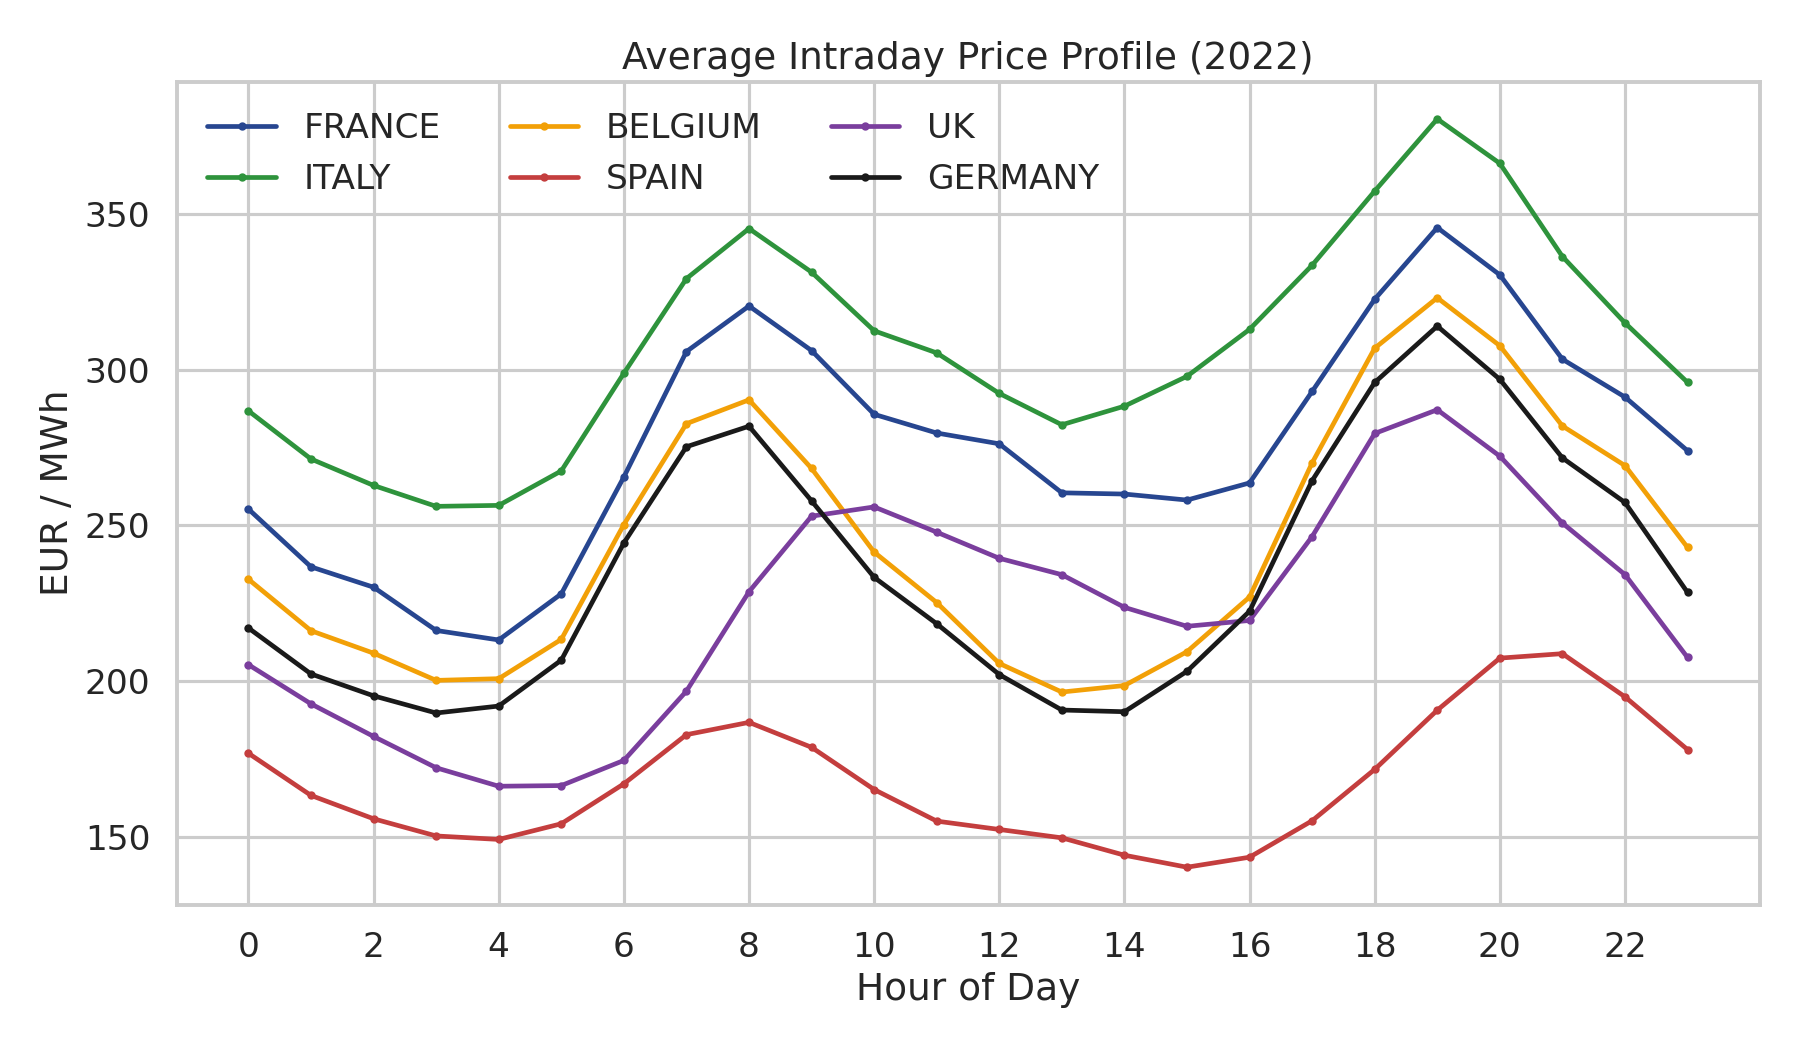

In [7]:
display(Image(filename="../outputs/figures/03_hourly_profile.png"))

Every market shows the classic **double-hump** daily profile: a morning ramp as people wake up and
businesses open, a midday dip (more pronounced where solar is a bigger share of the mix, e.g. Spain), and
an evening peak around 18:00–20:00 as households return home and solar drops off.

### 2.4 How correlated are these markets?

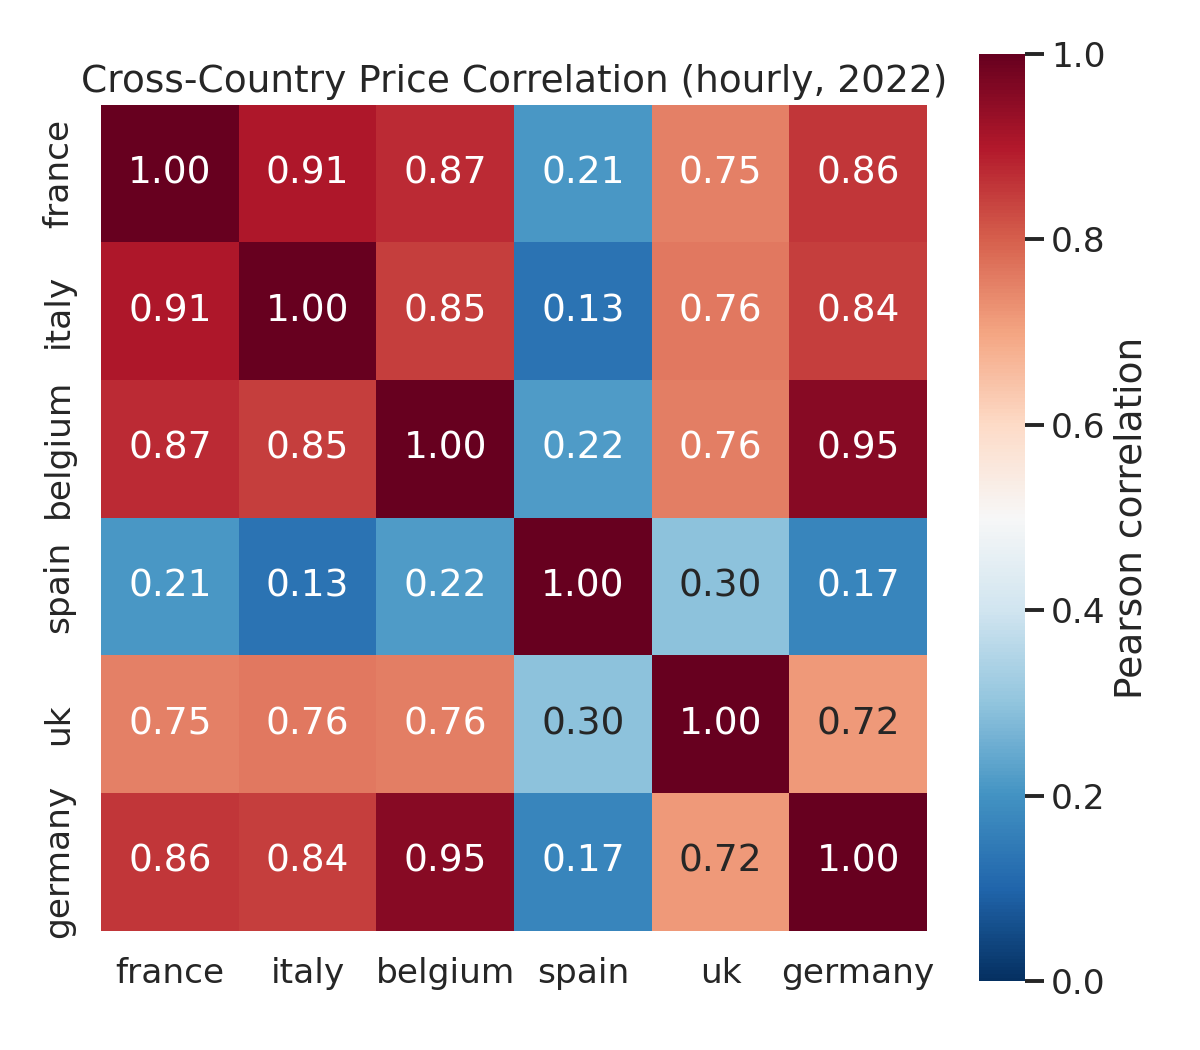

In [8]:
display(Image(filename="../outputs/figures/04_correlation_heatmap.png"))

Continental markets (France, Germany, Belgium) are extremely tightly coupled — expected, since they're
directly interconnected and were routinely price-coupled in 2022. The UK, which trades power with the
continent over a handful of interconnectors rather than a synchronous grid, correlates more loosely.
Spain (and Portugal) ran an EU-approved gas price cap ("Iberian exception") for part of 2022, which shows
up as a somewhat lower correlation with the rest of the continent too.

### 2.5 Negative prices: when the grid pays *you* to consume

In [9]:
display(neg_counts.to_frame("hours_with_negative_price"))

,hours_with_negative_price
belgium,112
germany,69
uk,51
france,4
italy,0
spain,0


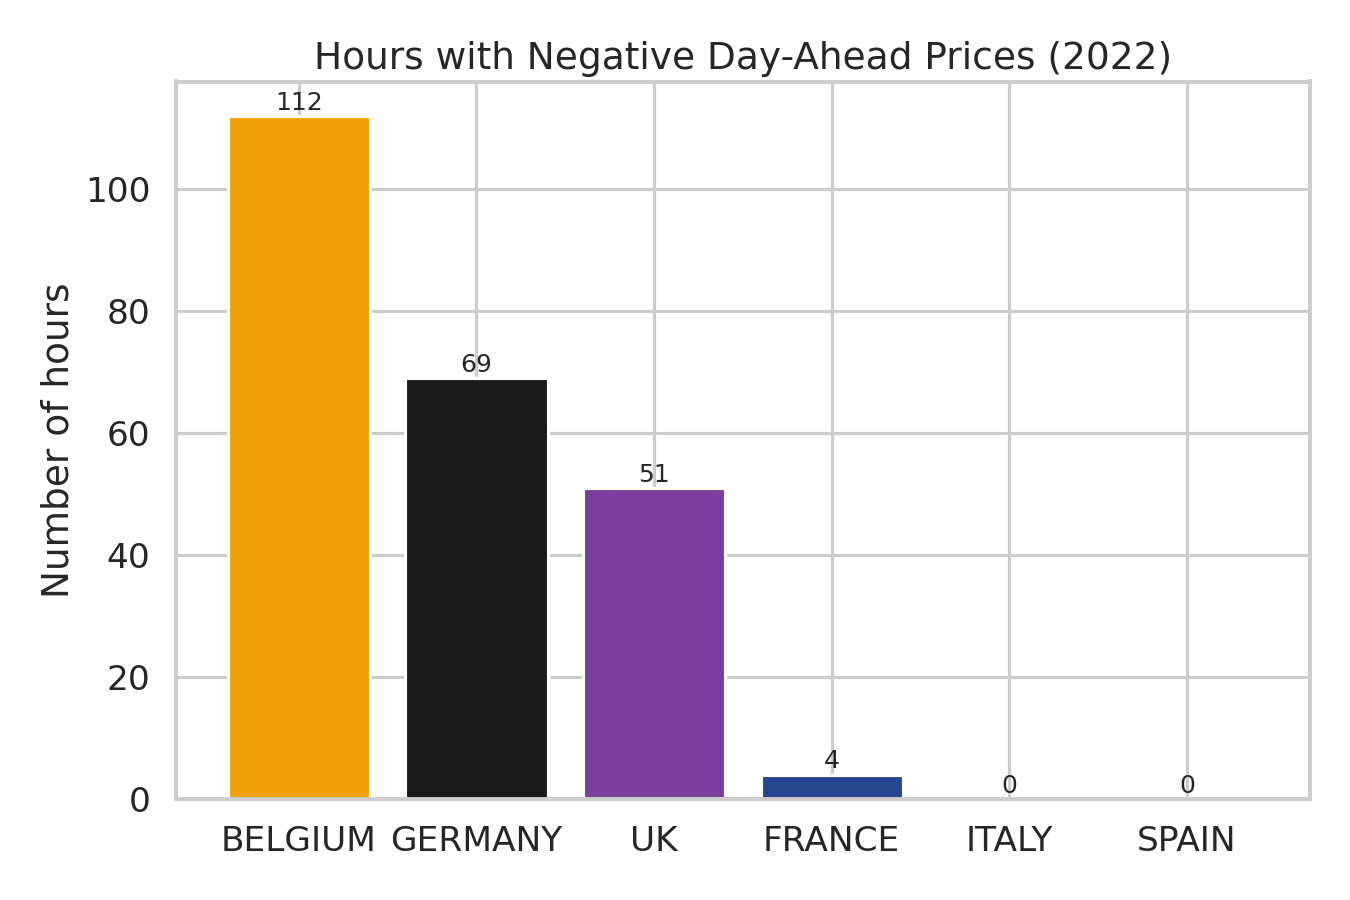

In [10]:
display(Image(filename="../outputs/figures/05_negative_price_hours.png"))

Negative prices happen when low demand meets a surplus of must-run generation (nuclear, wind, solar
that's expensive to curtail). Belgium and Germany — both with large nuclear and renewables fleets —
saw the most negative-price hours in 2022, concentrated around the low-demand year-end holiday period.

### 2.6 Volatility over time

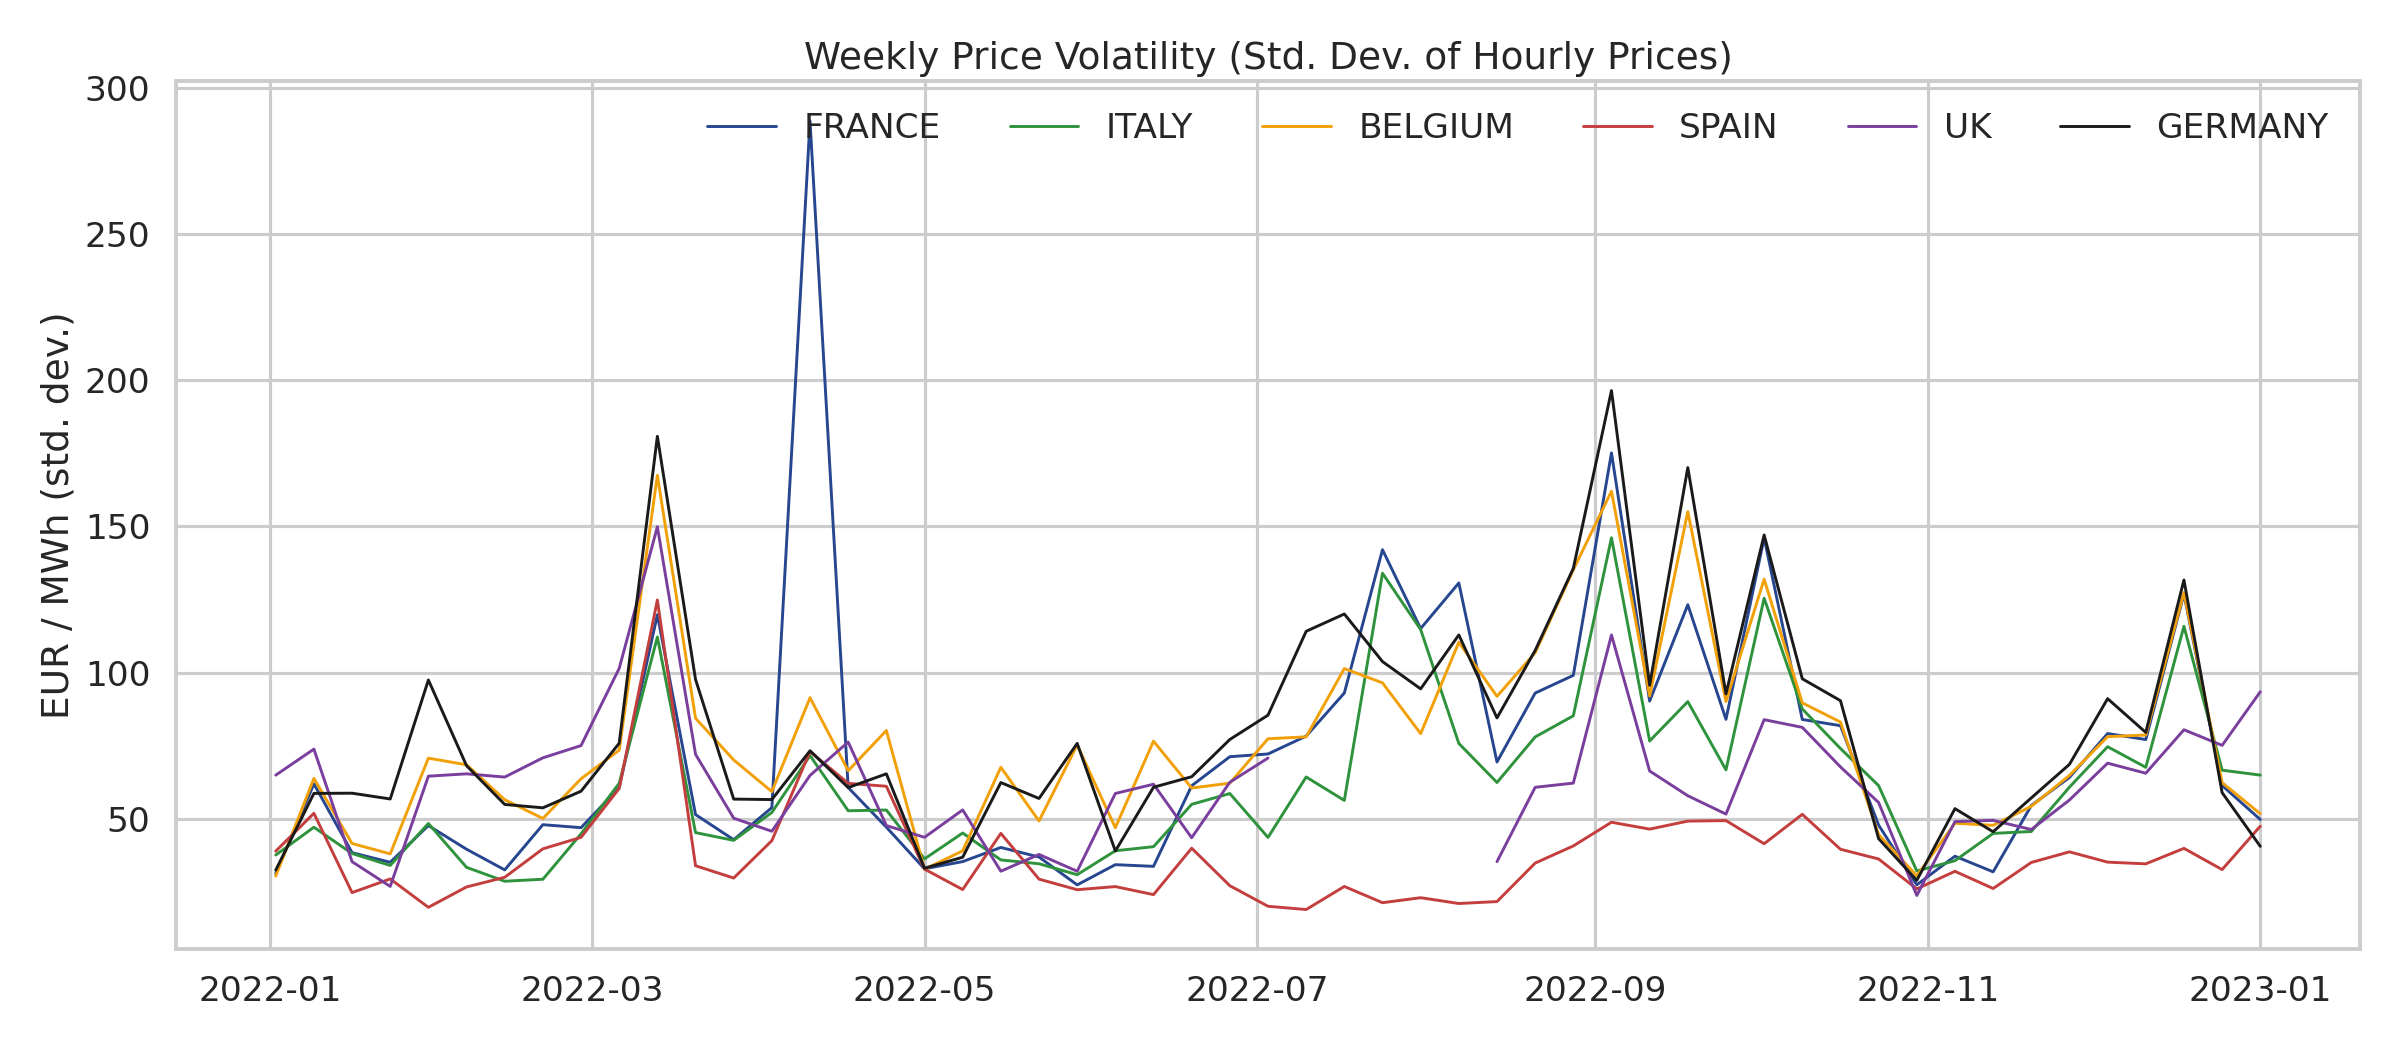

In [11]:
display(Image(filename="../outputs/figures/06_weekly_volatility.png"))

## 3. Feature Engineering

`src/features.py` builds a supervised-learning table for forecasting **Germany's price 24 hours ahead**:

- **Calendar features**: hour of day, day of week, month, weekend flag
- **Autoregressive lags** of Germany's own price: 24h, 25h, 48h, and 168h (1 week) back
- **Rolling statistics** (mean/std over the trailing 24h and 168h), computed only on *already-lagged*
  data so no future information leaks in
- **Cross-market signal**: France and Belgium prices, lagged 24h (the most recent value we'd actually
  have at forecast time)

The target is Germany's price shifted 24 hours into the future — i.e. at each timestamp `t`, we predict
the price at `t + 24h` using only information available at `t`.

In [12]:
from features import build_feature_matrix

feature_matrix = build_feature_matrix(df, target="germany", exog=("france", "belgium"))
print(feature_matrix.shape)
feature_matrix.head()


(8568, 15)


,hour,dayofweek,month,is_weekend,germany_lag24,...,germany_rollmean168,germany_rollstd168,france_lag24,belgium_lag24,target
timestamp,,,,,,,,,,,
2022-01-08 00:00:00,0,5,1,1,128.92,...,118.443214,63.242200,213.47,83.81,85.03
2022-01-08 01:00:00,1,5,1,1,118.40,...,119.122500,63.115945,189.00,87.77,84.40
2022-01-08 02:00:00,2,5,1,1,103.01,...,119.786190,62.878815,180.00,72.38,80.24
2022-01-08 03:00:00,3,5,1,1,101.91,...,120.517024,62.696831,164.90,76.79,55.46
2022-01-08 04:00:00,4,5,1,1,101.98,...,121.203929,62.501440,162.80,77.70,49.29


## 4. Forecasting Models

We hold out the **last 8 weeks of 2022** as a chronological test set (no random shuffling — this is a
time series, and shuffling would leak future information into training).

Four models are compared:
1. **Naive seasonal baseline**: predict tomorrow's price = the same hour, one week ago
2. **Linear Regression**
3. **Random Forest**
4. **XGBoost**

Full training/evaluation code lives in `src/model.py`.

In [13]:
from model import run as run_model
results_df, predictions = run_model()
results_df


                            MAE    RMSE  MAPE_%
model                                          
Naive Seasonal (t-168h)  104.40  133.32   112.6
Linear Regression         67.57   81.19    65.0
Random Forest             69.72   84.21    79.3
XGBoost                   72.09   88.16    76.8


,MAE,RMSE,MAPE_%
model,,,
Naive Seasonal (t-168h),104.40,133.32,112.6
Linear Regression,67.57,81.19,65.0
Random Forest,69.72,84.21,79.3
XGBoost,72.09,88.16,76.8


All three ML models beat the naive seasonal baseline by a wide margin on both MAE and RMSE. Linear
Regression is a strong, simple baseline here — the target is dominated by a few highly linear signals
(yesterday's price, last week's rolling average), so the extra flexibility of tree ensembles doesn't pay
off much on a single year of data. (MAPE is reported with a floor near zero, since day-ahead prices can
sit at ~0 EUR/MWh or go negative, where percentage error is not a stable metric — MAE/RMSE, in EUR/MWh,
are the primary numbers to trust.)

### 4.1 Forecast vs. actual

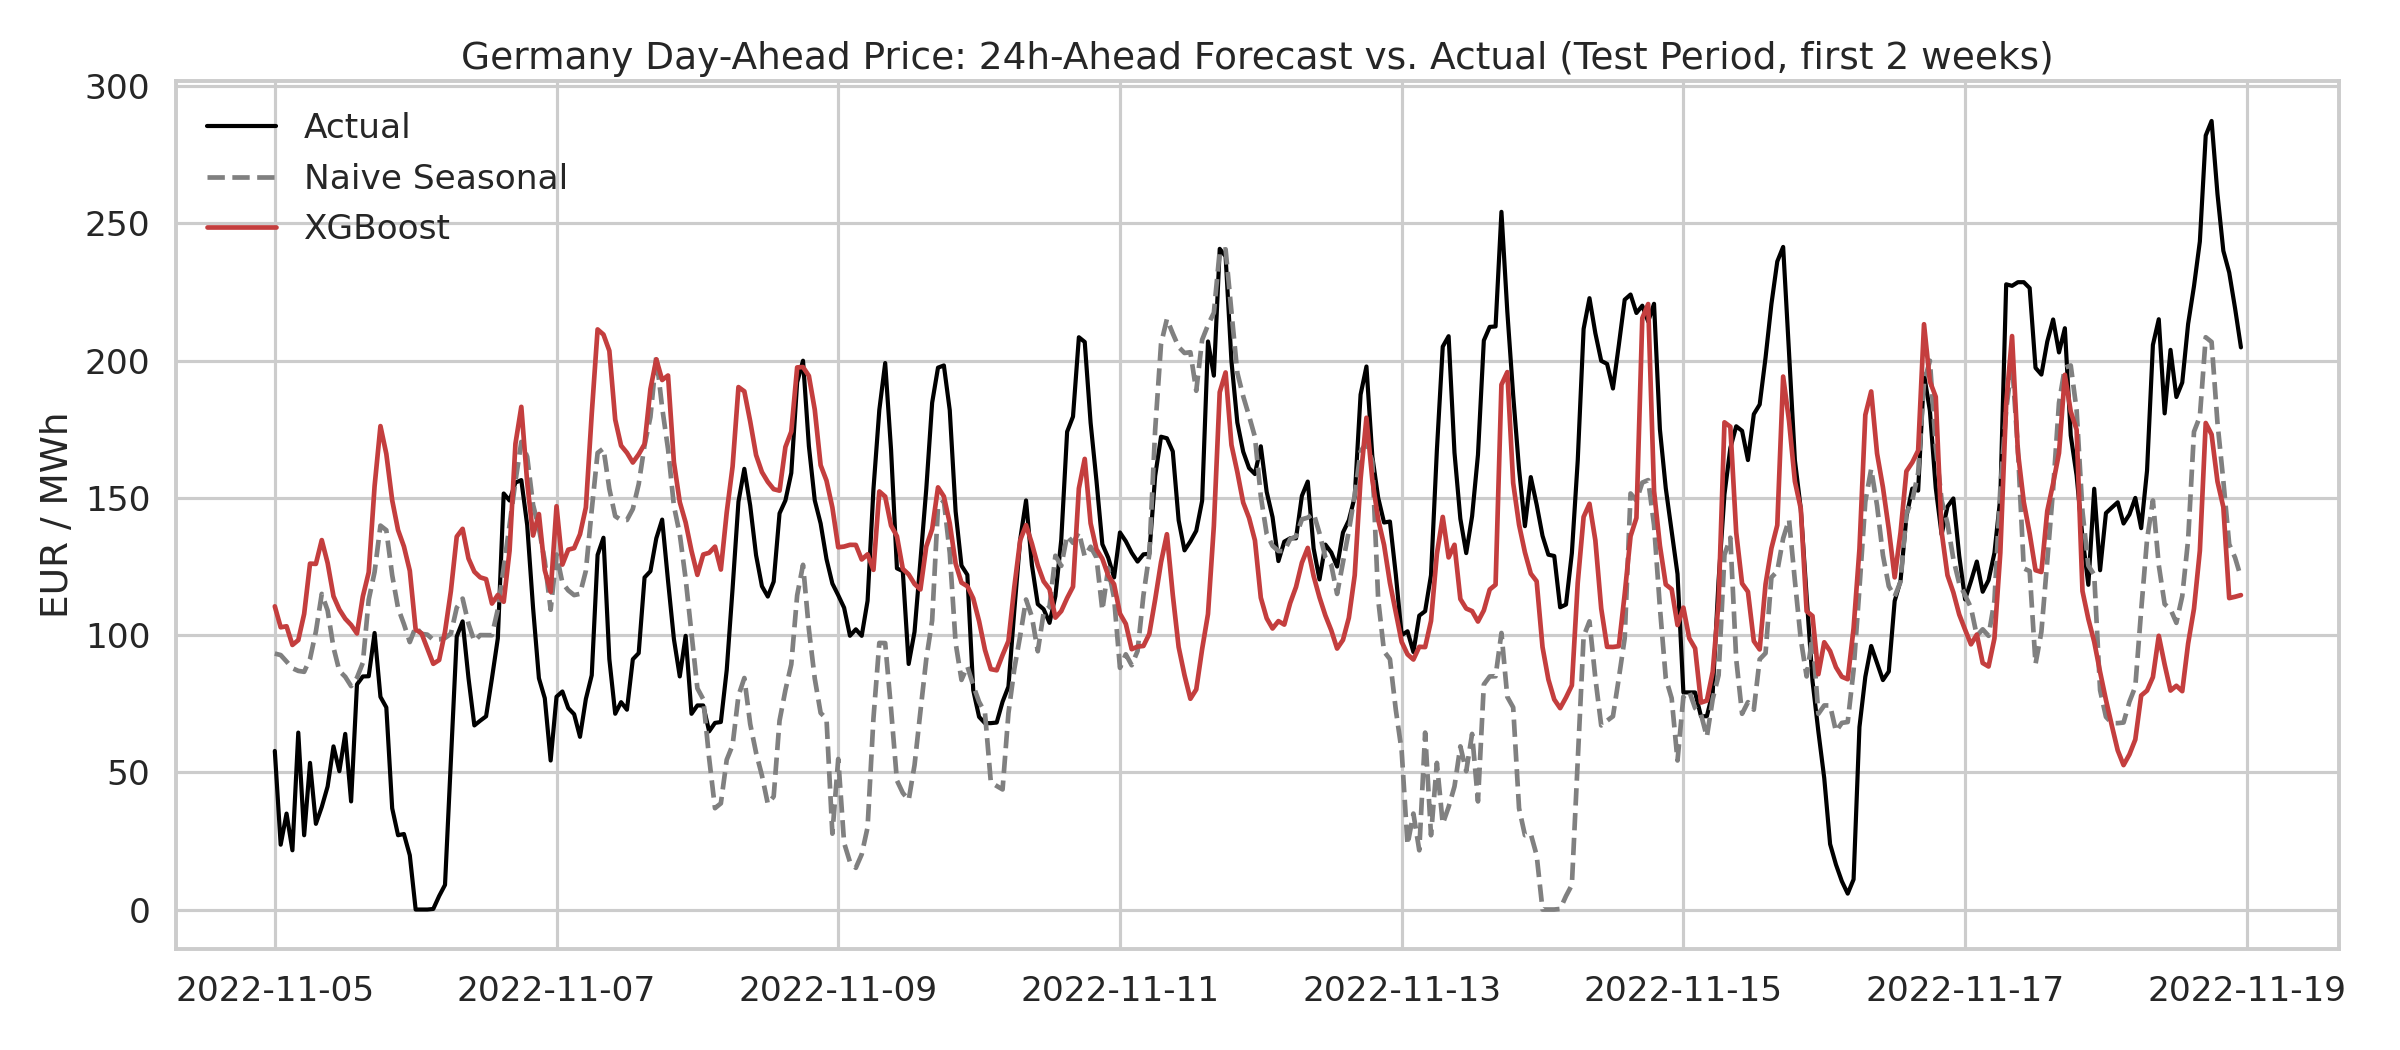

In [14]:
display(Image(filename="../outputs/figures/07_forecast_vs_actual.png"))

### 4.2 What drives the forecast?

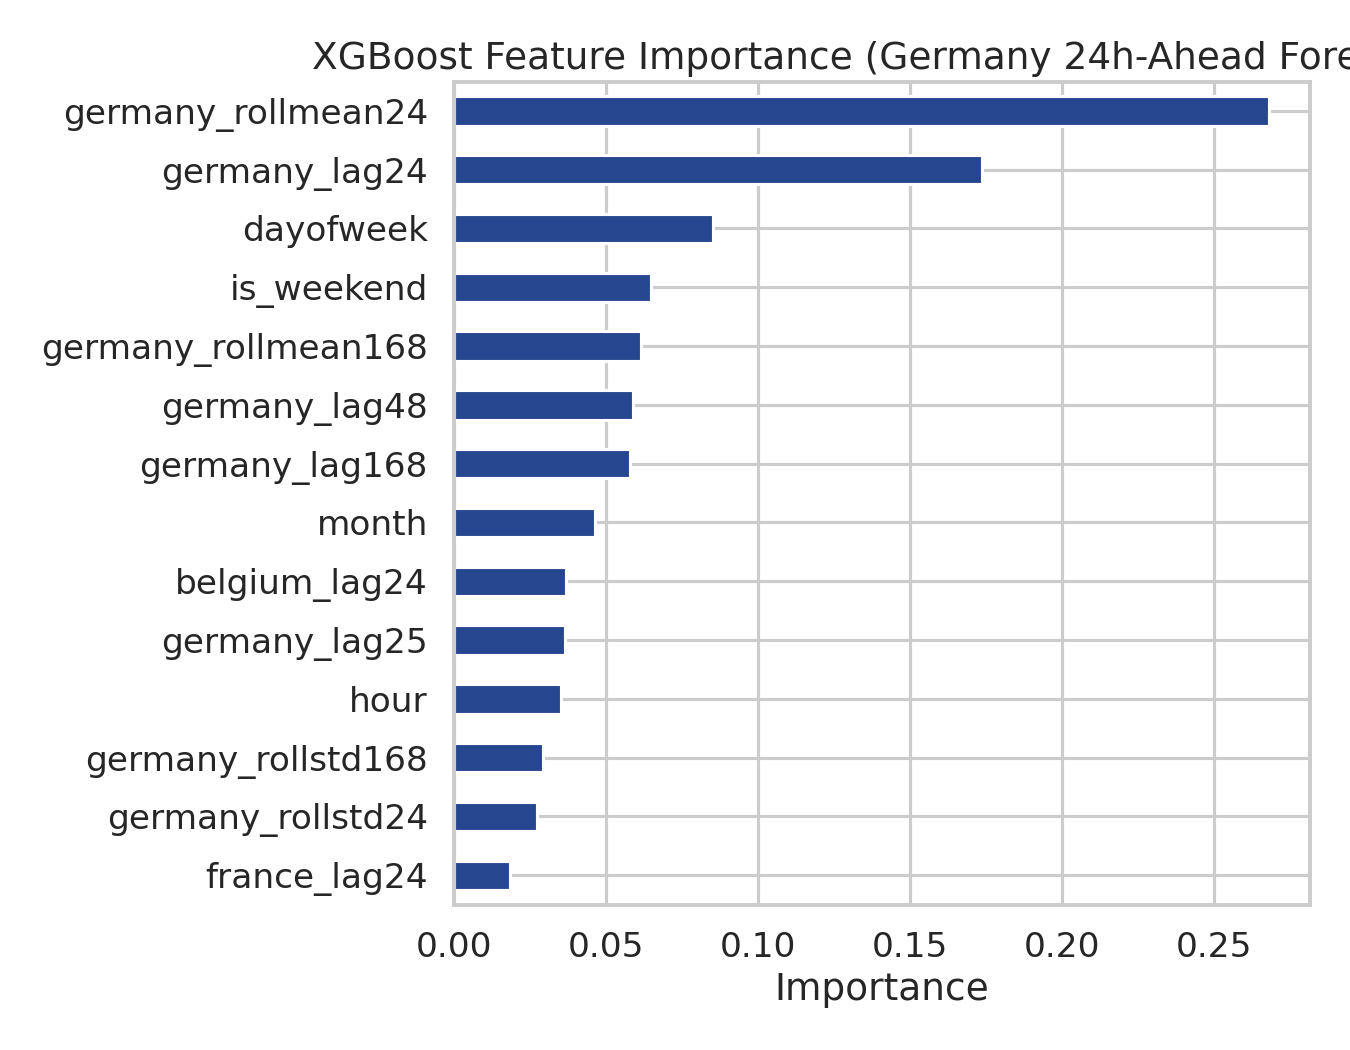

In [15]:
display(Image(filename="../outputs/figures/08_feature_importance.png"))

Unsurprisingly, the trailing 24-hour rolling average and yesterday's same-hour price dominate — power
prices are strongly autocorrelated at daily and weekly cycles. Day-of-week and weekend flags matter more
than the hour itself once lag/rolling features are included, since those already encode most of the
intraday shape.

### 4.3 Model comparison

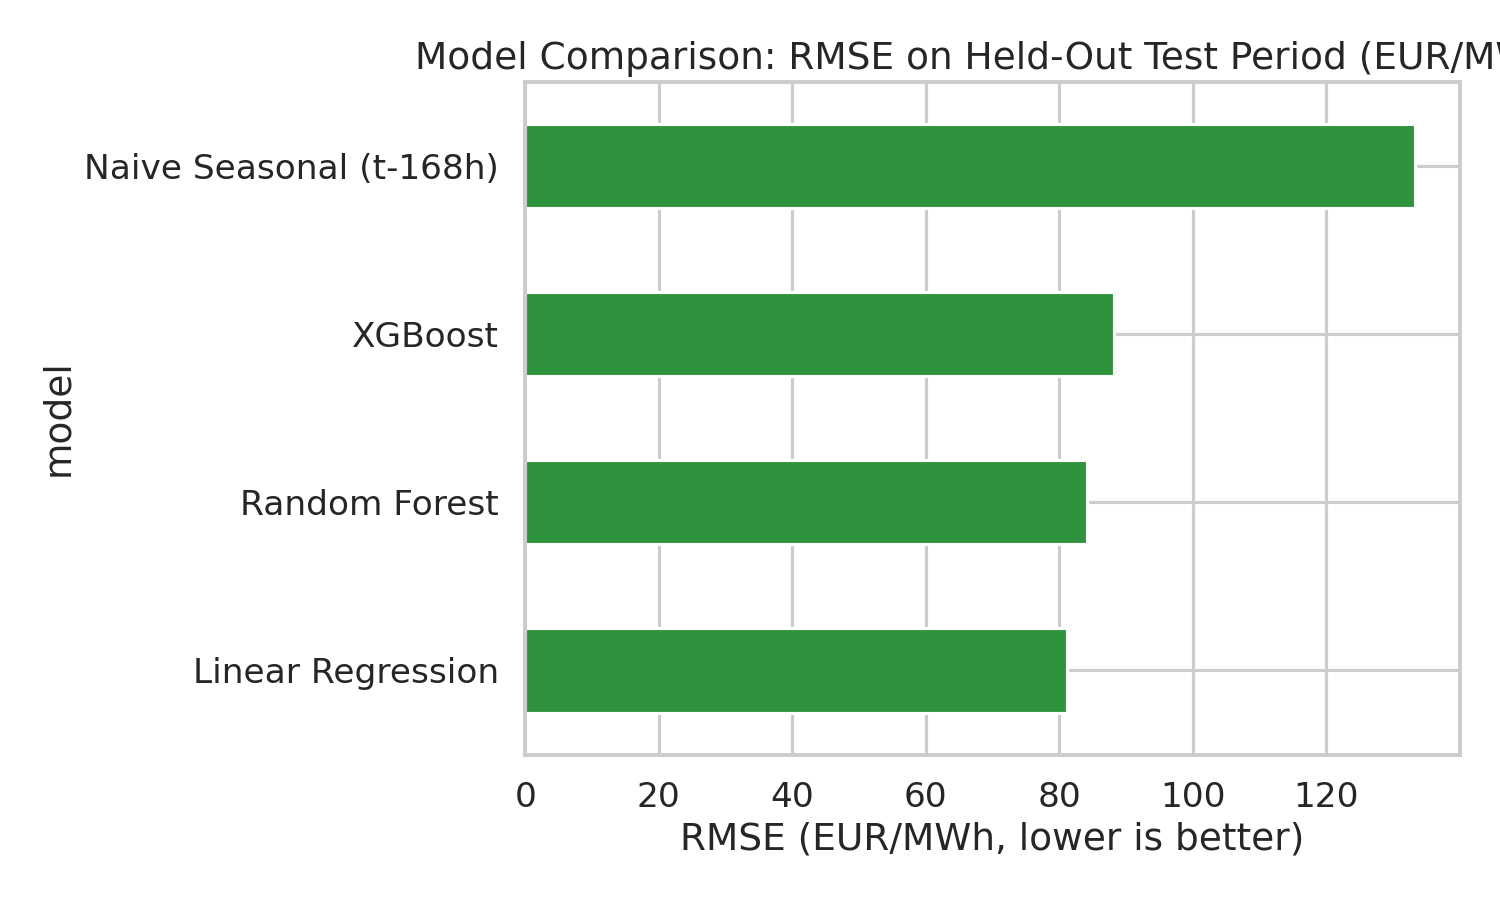

In [16]:
display(Image(filename="../outputs/figures/09_model_comparison.png"))

## 5. Takeaways

- **2022 was an extreme year** for European power markets: the gas-supply shock from the Ukraine war
  pushed day-ahead prices 3-5x above typical levels at the August peak, with clearly visible co-movement
  across every interconnected market.
- **Autoregressive structure dominates**: a well-chosen set of lag and rolling features gets most of the
  way to a good 24h-ahead forecast; cross-market and calendar features add smaller, second-order gains.
- **Simple models are competitive**: with a single year of hourly data, Linear Regression matches or beats
  tree ensembles — a reminder to always benchmark against a strong simple baseline before reaching for
  more complex models.
- **Data quality matters**: the UK series' missing hours were a real modeling constraint, handled by
  scoping the forecasting target to the more complete continental markets rather than dropping or
  fabricating data.

### Next steps
- Add weather/demand data (temperature, wind/solar generation forecasts) as exogenous features
- Probabilistic forecasting (quantile regression) to capture price-spike risk, not just the point forecast
- Extend to multi-country joint forecasting
